In [1]:
import pandas as pd
import sys
import os
import jax
from arviz.labels import MapLabeller
import numpy as np

sys.path.append(os.path.abspath(os.path.join('../..')))

from utils.modeling import (
    encode_categorical_covariates, 
    fit_model_and_extract_idata,
    )

from utils.plotting import (
    plot_predictive_distributions,
    plot_combined_figure,
    plot_krippendorff_comparison
)

from utils.metrics import (
    compute_observed_krippendorff, 
    compute_krippendorff_from_predictions, 
    compute_bias_corrected_alpha_simple
)

/home/ubuntu/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load data

In [2]:
df = pd.read_csv('data.csv')

# Check
print('Unique graders:', set(df['grader']))
print('Unique models:', set(df['LLM']))
df.head(5)

Unique graders: {'Autograder A', 'Autograder B', 'Human'}
Unique models: {'LLM A', 'LLM B'}


,score,grader,LLM,item
0,8,Human,LLM A,1
1,10,Human,LLM A,1
2,9,Human,LLM A,1
3,10,Human,LLM A,1
4,9,Human,LLM A,1


# Fit model

In [3]:
# Define covariates and outcome
main_effects = ['grader', 'item', 'LLM']  # categorical variables
interactions = [('grader', 'item')]
outcome = 'score'  # ordinal variable, 0–10

# Encode categorical covariates
covariates_dict, category_maps = encode_categorical_covariates(df, main_effects)

# Encore the outcome
allowed_scores = list(range(11))  # ordinal values: 0–10
score_map = {val: i for i, val in enumerate(allowed_scores)}
y = df[outcome].map(score_map).values

# Fit models
rng_key = jax.random.PRNGKey(0)

## Model with interaction
mcmc_with_interaction, idata_with_interaction = fit_model_and_extract_idata(
    rng_key, covariates_dict, y, main_effects, interactions, category_maps
)

sample: 100%|██████████| 2000/2000 [00:09<00:00, 205.43it/s, 63 steps of size 1.24e-01. acc. prob=0.90]


# Fitted parameters

In [4]:
mcmc_with_interaction.print_summary()


                                   mean       std    median      5.0%     95.0%     n_eff     r_hat
                     b_LLM[0]      1.66      0.09      1.66      1.52      1.82   1019.75      1.00
                  b_grader[0]     -1.49      0.40     -1.50     -2.14     -0.86    471.50      1.00
                  b_grader[1]     -1.94      0.38     -1.93     -2.59     -1.37    379.80      1.00
 b_interaction_grader_item[0]      0.36      0.70      0.35     -0.85      1.44    426.00      1.00
 b_interaction_grader_item[1]      0.18      0.68      0.18     -0.89      1.31    584.45      1.00
 b_interaction_grader_item[2]     -0.22      0.66     -0.21     -1.31      0.83    432.75      1.00
 b_interaction_grader_item[3]     -0.17      0.68     -0.16     -1.41      0.79    559.58      1.00
 b_interaction_grader_item[4]      0.04      0.66      0.04     -1.00      1.17    398.20      1.00
 b_interaction_grader_item[5]     -0.19      0.67     -0.22     -1.18      0.99    462.60      1.00

## Checks

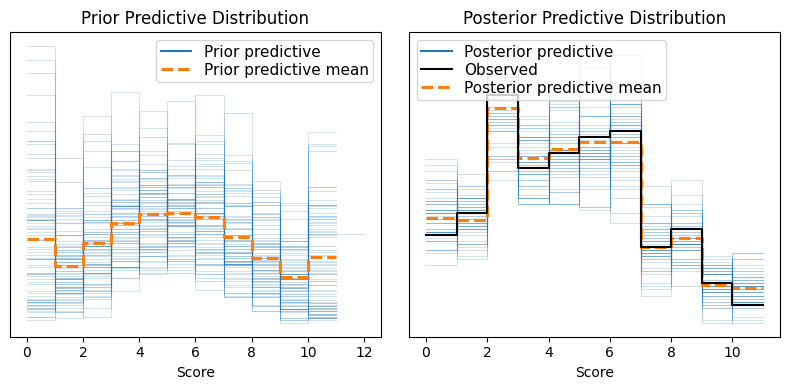

In [5]:
plot_predictive_distributions(idata_with_interaction, fig_path="fig_predictive.png")

# Figure

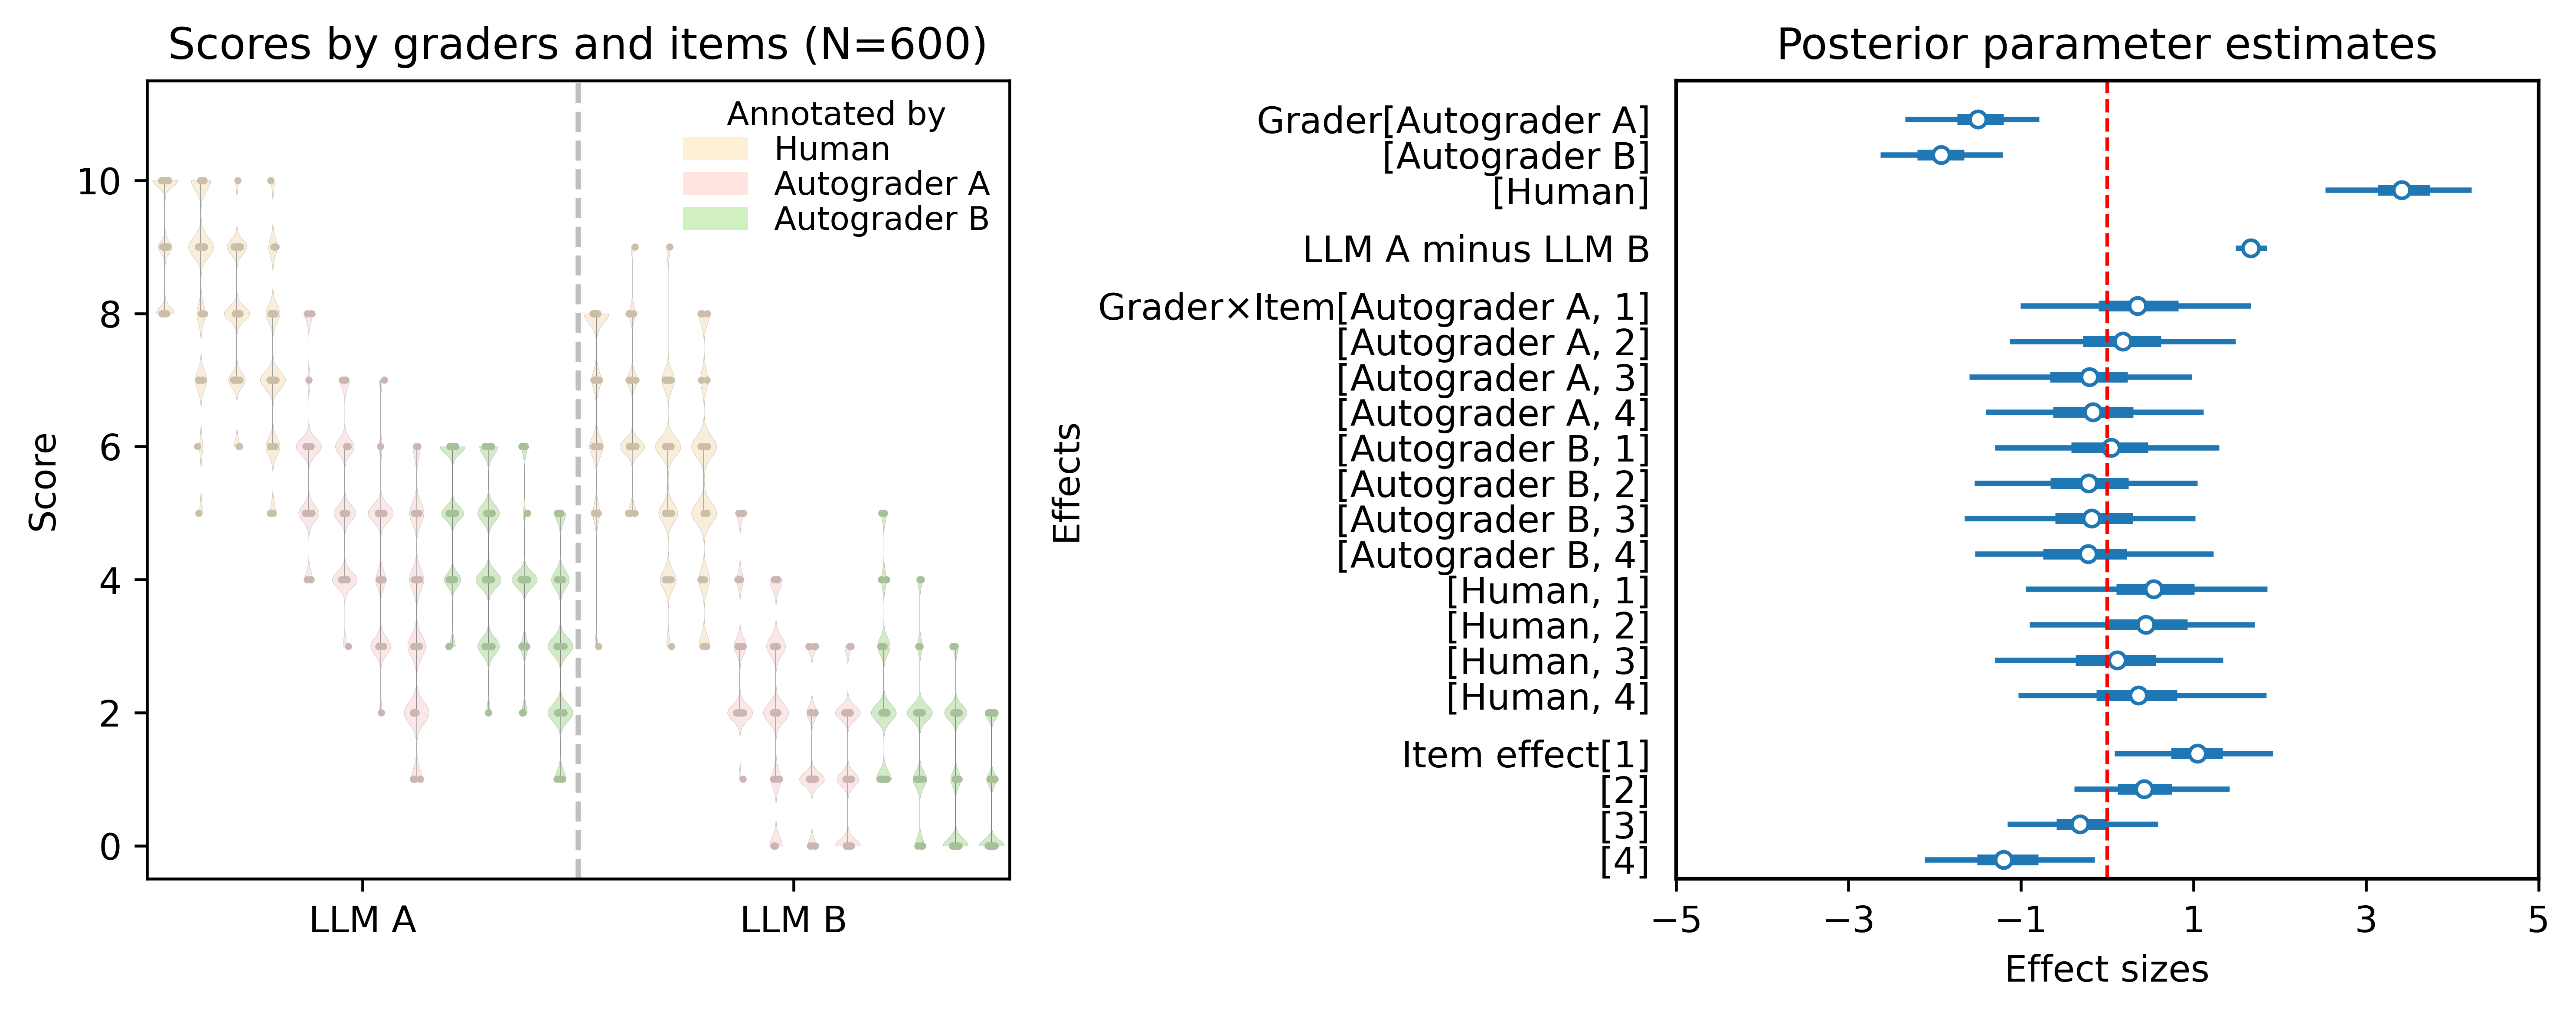

In [11]:
labeller = MapLabeller(
        var_name_map={
            "b_grader_full": "Grader",
            "b_LLM": "LLM A minus LLM B",  
            "b_interaction_grader_item_full": "Grader×Item",
            "b_item_full": "Item effect",
        }
    )

plot_combined_figure(
    df=df,
    idata=idata_with_interaction,
    var_names=[
        "b_grader_full",
        "b_LLM",
        "b_interaction_grader_item_full",
        "b_item_full"
    ],
    labeller=labeller,
    color_scheme='2autograders',
    x_var='LLM',
    x_label=None,
    dodge=True,
    fig_path="../../figures/figure5.png",
    legend_title='Annotated by',
    xlim=[-5.0, 5.0],
    show_items=True,  
    show_predictions=False,
    pred_alpha=0.2,
    category_maps=category_maps,
    legend_fontsize=9,
)

# Average betas

In [7]:
# Interater agreement on observed data
alpha_observed = compute_observed_krippendorff(df)
print(f"Raw observed α: {alpha_observed:.3f}")

Raw observed α: -0.222


In [8]:
# Get posterior predictions and flatten
posterior_pred = idata_with_interaction.posterior_predictive['obs'].values
if len(posterior_pred.shape) == 3:
    posterior_pred_flat = posterior_pred.reshape(-1, posterior_pred.shape[-1])
else:
    posterior_pred_flat = posterior_pred

# Compute inter-rater agreement on GLM predictions
n_samples = min(100, posterior_pred_flat.shape[0])
alphas = [compute_krippendorff_from_predictions(posterior_pred_flat[i, :], df) 
          for i in range(n_samples)]

valid_predictions = np.array(alphas)[~np.isnan(alphas)]
predictions_mean = np.mean(valid_predictions)
predictions_ci = np.percentile(valid_predictions, [2.5, 97.5])

print(f"GLM predictions α: {predictions_mean:.3f} [{predictions_ci[0]:.3f}, {predictions_ci[1]:.3f}]")

GLM predictions α: -0.215 [-0.269, -0.163]


In [9]:
# Compute bias-corrected α for posterior samples
n_samples = min(100, idata_with_interaction.posterior['intercept'].values.shape[1])

bias_corrected_alphas = []
for i in range(n_samples):
    alpha_i = compute_bias_corrected_alpha_simple(
        i, df, idata_with_interaction, covariates_dict, main_effects, interactions
    )
    bias_corrected_alphas.append(alpha_i)

valid_corrected = np.array(bias_corrected_alphas)
valid_corrected = valid_corrected[~np.isnan(valid_corrected)]

if len(valid_corrected) > 0:
    corrected_mean = np.mean(valid_corrected)
    corrected_ci = np.percentile(valid_corrected, [2.5, 97.5])
    print(f"Bias-corrected α: {corrected_mean:.3f} [{corrected_ci[0]:.3f}, {corrected_ci[1]:.3f}]")
else:
    print("No valid bias-corrected samples computed")
    corrected_mean, corrected_ci = np.nan, [np.nan, np.nan]

Bias-corrected α: 0.731 [0.462, 0.921]


# Plot

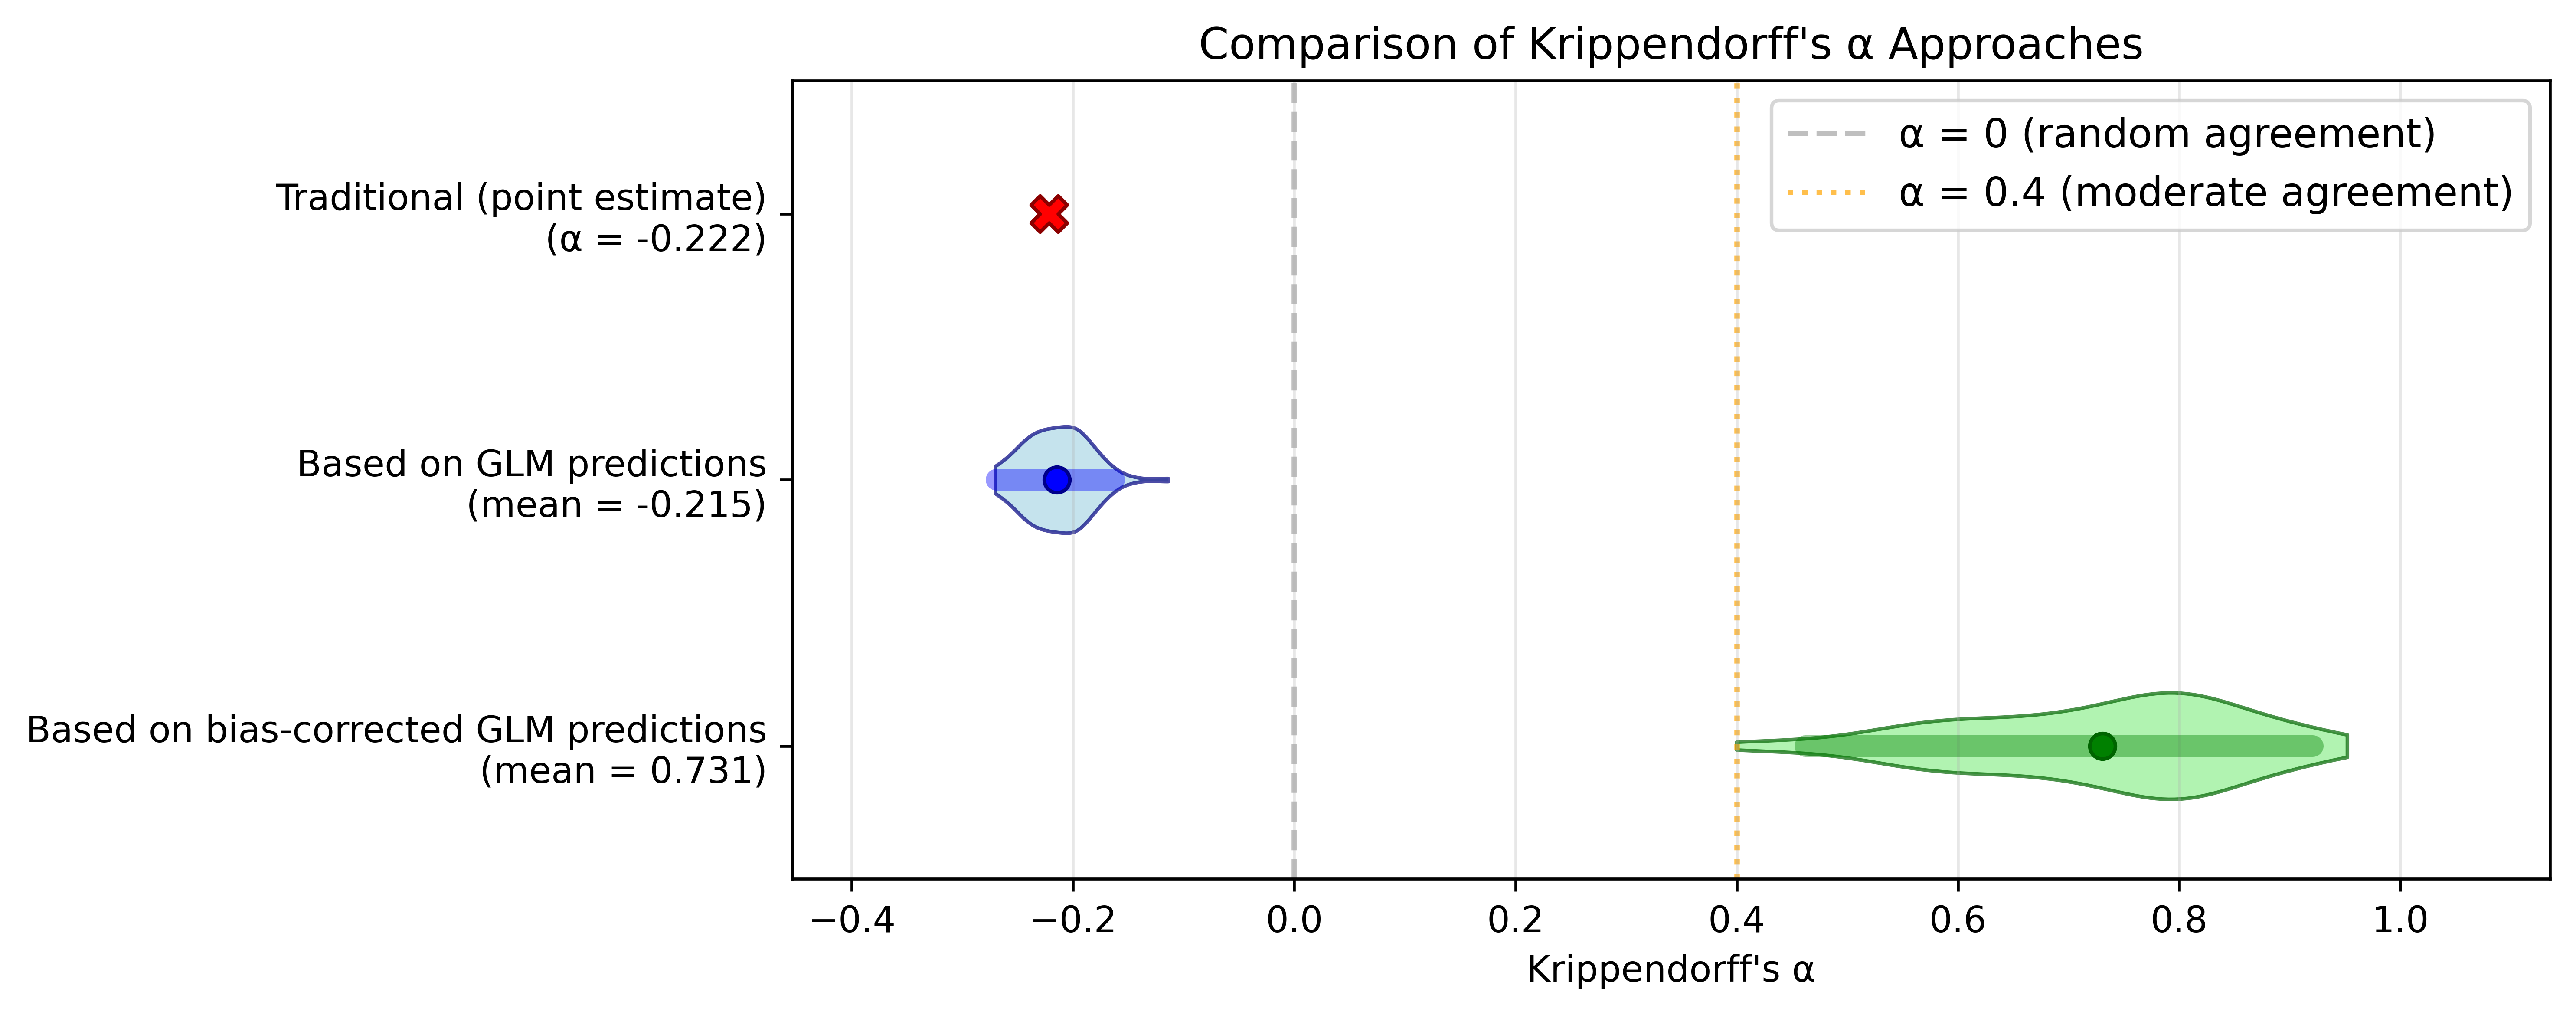

In [10]:
plot_krippendorff_comparison(alpha_observed, valid_predictions, valid_corrected, 
                                  predictions_mean, predictions_ci, corrected_mean, corrected_ci, 
                                  fig_path = "../../figures/figure5_alpha.png",
                                  trad_s=100, trad_linewidth=1, glm_s=50, glm_linewidth=1)